# AI Security Project — Phases 2 & 3: Attacks & Defenses (v2)
**Dataset:** SMS Spam Collection Dataset  
**Task:** Binary Text Classification — Spam vs Ham  
**Model:** Logistic Regression + TF-IDF  

---

## Overview

| Phase | Task | Technique |
|---|---|---|
| **Phase 2** | Adversarial Attacks | **Attack 1:** Strong Homoglyph Substitution · **Attack 2:** Targeted Keyword Deletion |
| **Phase 3** | Defense Techniques | **Defense 1:** Extended Character Normalization · **Defense 2:** Adversarial Training |

---
## 0. Setup — Reproduce Baseline

In [1]:
import pandas as pd
import numpy as np
import re
import random
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

random.seed(42)
np.random.seed(42)
print('Libraries imported.')

Libraries imported.


In [2]:
# ── Load & preprocess ─────────────────────────────────────────────
df = pd.read_csv('../data/spam.csv', encoding='latin-1')
df = df[['v1', 'v2']].copy()
df.columns = ['label', 'message']

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\b\d{7,}\b', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

df['clean_message'] = df['message'].apply(preprocess_text)
df['label_enc']     = df['label'].map({'spam': 1, 'ham': 0})

X = df['clean_message']
y = df['label_enc']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── TF-IDF + Logistic Regression ──────────────────────────────────
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, sublinear_tf=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

clf = LogisticRegression(
    C=1.0, solver='liblinear',
    class_weight='balanced', max_iter=1000, random_state=42
)
clf.fit(X_train_tfidf, y_train)

# ── Metric helper ─────────────────────────────────────────────────
def metrics(y_true, y_pred):
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_true, y_pred, zero_division=0),
    }

y_pred_baseline = clf.predict(X_test_tfidf)
baseline_metrics = metrics(y_test, y_pred_baseline)

print('=== BASELINE MODEL ===')
for k, v in baseline_metrics.items():
    print(f'  {k:<12}: {v:.4f}')

=== BASELINE MODEL ===
  Accuracy    : 0.9821
  Precision   : 0.9388
  Recall      : 0.9262
  F1-Score    : 0.9324


---
# PHASE 2 — Adversarial Attacks

Both attacks are **black-box** — they only manipulate the text without accessing model weights or gradients.

| | Attack | Core Idea | Why It Works Against TF-IDF |
|---|---|---|---|
| **Attack 1** | Strong Homoglyph Substitution | Replace 8 common characters with symbols at a 90% word rate | Corrupted tokens are out-of-vocabulary → zero TF-IDF weight → spam keywords invisible |
| **Attack 2** | Targeted Keyword Deletion | Extract the model's top-50 spam-indicative features and delete them from messages | Directly removes the exact evidence the model relies on to classify spam |

## Attack 1 — Strong Homoglyph / Character Substitution

### What changed vs. the basic version
The original attack used a 30% word substitution rate and only 5 character mappings. This version uses:
- **90% substitution rate** — nearly every word gets corrupted
- **8-character mapping** — expands to include `t→+`, `l→|`, `g→9`

This is realistic: real-world spammers use exactly this technique to bypass keyword filters.

### Substitution Map
| `a→@` | `e→3` | `i→1` | `o→0` | `s→$` | `t→+` | `l→\|` | `g→9` |

In [3]:
CHAR_MAP = {'a': '@', 'e': '3', 'i': '1', 'o': '0',
            's': '$', 't': '+', 'l': '|', 'g': '9'}

def homoglyph_attack_strong(text, rate=0.9):
    """
    Replace common characters with look-alike symbols.
    rate=0.9 means 90% of words get corrupted.
    """
    rng = random.Random(42)
    words = text.split()
    return ' '.join(
        ''.join(CHAR_MAP.get(c, c) for c in w) if rng.random() < rate else w
        for w in words
    )

# Apply to test set
X_test_atk1      = X_test.apply(homoglyph_attack_strong)
X_test_atk1_tfidf = vectorizer.transform(X_test_atk1)
y_pred_atk1      = clf.predict(X_test_atk1_tfidf)
atk1_metrics     = metrics(y_test, y_pred_atk1)

print('=== AFTER ATTACK 1 — Strong Homoglyph Substitution ===')
for k, v in atk1_metrics.items():
    delta = v - baseline_metrics[k]
    arrow = '▼' if delta < 0 else '▲'
    print(f'  {k:<12}: {v:.4f}   Δ {arrow}{abs(delta)*100:.2f}%')

=== AFTER ATTACK 1 — Strong Homoglyph Substitution ===
  Accuracy    : 0.8619   Δ ▼12.02%
  Precision   : 0.4419   Δ ▼49.69%
  Recall      : 0.1275   Δ ▼79.87%
  F1-Score    : 0.1979   Δ ▼73.45%


In [4]:
# ── Before / after examples ───────────────────────────────────────
print('=== Attack 1 — Message Examples (Spam class) ===')
print()

spam_orig = X_test[y_test == 1].head(4)
spam_atk1 = X_test_atk1[y_test == 1].head(4)

for i, (orig, atk) in enumerate(zip(spam_orig, spam_atk1), 1):
    o_prob = clf.predict_proba(vectorizer.transform([orig]))[0][1]
    a_prob = clf.predict_proba(vectorizer.transform([atk]))[0][1]
    o_pred = 'SPAM' if o_prob >= 0.5 else 'HAM'
    a_pred = 'SPAM' if a_prob >= 0.5 else 'HAM'
    evaded = '  ⚠ EVADED DETECTION' if o_pred == 'SPAM' and a_pred == 'HAM' else ''
    print(f'  [{i}] ORIGINAL : "{orig[:75]}"')
    print(f'      ATTACKED : "{atk[:75]}"')
    print(f'      Before → {o_pred} ({o_prob:.3f})   |   After → {a_pred} ({a_prob:.3f}){evaded}')
    print()

=== Attack 1 — Message Examples (Spam class) ===

  [1] ORIGINAL : "you have won cash or a prize to claim call"
      ATTACKED : "y0u h@v3 w0n c@$h 0r @ pr1z3 +0 c|@1m c@||"
      Before → SPAM (0.990)   |   After → HAM (0.182)  ⚠ EVADED DETECTION

  [2] ORIGINAL : "you are now unsubscribed all services get tons of sexy babes or hunks strai"
      ATTACKED : "y0u @r3 n0w un$ub$cr1b3d @|| $3rv1c3$ 93+ +0n$ 0f $3xy b@b3$ 0r hunk$ $+r@1"
      Before → SPAM (0.835)   |   After → HAM (0.182)  ⚠ EVADED DETECTION

  [3] ORIGINAL : "wanna get laid nite want real dogging locations sent direct to ur mobile jo"
      ATTACKED : "w@nn@ 93+ |@1d n1+3 w@n+ r3@| d0991n9 |0c@+10n$ $3n+ d1r3c+ +0 ur m0b1|3 j0"
      Before → SPAM (0.926)   |   After → SPAM (0.585)

  [4] ORIGINAL : "do you want anytime any network mins text and a new video phone for only fi"
      ATTACKED : "d0 y0u w@n+ @ny+1m3 @ny n3+w0rk m1n$ +3x+ @nd @ n3w v1d30 ph0n3 f0r 0n|y f1"
      Before → SPAM (0.942)   |   After → HAM (0.4

## Attack 2 — Targeted Keyword Deletion

### Idea
This is a **white-box-inspired, black-box-applicable** attack. Instead of random perturbation, it exploits direct knowledge of how TF-IDF + Logistic Regression works:

1. Extract the **top-50 features** with the highest positive coefficients in the trained model — these are the words that push predictions toward *spam*.
2. **Delete those exact words** from every test message before classification.

Without its most discriminative evidence, the model is left guessing. This is much more surgical than random noise and reflects real adversarial knowledge.

In [5]:
# ── Extract top spam-indicative features ─────────────────────────
feature_names  = vectorizer.get_feature_names_out()
spam_coefs     = clf.coef_[0]
top_spam_idx   = np.argsort(spam_coefs)[-50:]
top_spam_words = set(feature_names[i] for i in top_spam_idx)

print('Top 20 spam-indicative features (highest LR coefficients):')
sorted_top = sorted(top_spam_idx, key=lambda i: spam_coefs[i], reverse=True)
for rank, idx in enumerate(sorted_top[:20], 1):
    print(f'  {rank:>2}. {feature_names[idx]:<25} coef = {spam_coefs[idx]:.3f}')

Top 20 spam-indicative features (highest LR coefficients):
   1. txt                       coef = 5.257
   2. call                      coef = 5.240
   3. free                      coef = 4.335
   4. text                      coef = 3.805
   5. to                        coef = 3.547
   6. reply                     coef = 3.470
   7. stop                      coef = 3.304
   8. from                      coef = 3.290
   9. your                      coef = 3.126
  10. claim                     coef = 3.069
  11. mobile                    coef = 3.052
  12. win                       coef = 2.548
  13. or                        coef = 2.545
  14. now                       coef = 2.535
  15. chat                      coef = 2.488
  16. ringtone                  coef = 2.476
  17. service                   coef = 2.349
  18. won                       coef = 2.329
  19. prize                     coef = 2.232
  20. for                       coef = 2.192


In [6]:
# ── Apply attack ──────────────────────────────────────────────────
def keyword_deletion_attack(text):
    """Remove all top-50 spam keywords from the message."""
    return ' '.join(w for w in text.split() if w not in top_spam_words)

X_test_atk2       = X_test.apply(keyword_deletion_attack)
X_test_atk2_tfidf = vectorizer.transform(X_test_atk2)
y_pred_atk2       = clf.predict(X_test_atk2_tfidf)
atk2_metrics      = metrics(y_test, y_pred_atk2)

print('=== AFTER ATTACK 2 — Targeted Keyword Deletion ===')
for k, v in atk2_metrics.items():
    delta = v - baseline_metrics[k]
    arrow = '▼' if delta < 0 else '▲'
    print(f'  {k:<12}: {v:.4f}   Δ {arrow}{abs(delta)*100:.2f}%')

=== AFTER ATTACK 2 — Targeted Keyword Deletion ===
  Accuracy    : 0.9345   Δ ▼4.75%
  Precision   : 1.0000   Δ ▲6.12%
  Recall      : 0.5101   Δ ▼41.61%
  F1-Score    : 0.6756   Δ ▼25.69%


In [7]:
# ── Before / after examples ───────────────────────────────────────
print('=== Attack 2 — Message Examples (Spam class) ===')
print()

spam_atk2 = X_test_atk2[y_test == 1].head(4)

for i, (orig, atk) in enumerate(zip(spam_orig, spam_atk2), 1):
    o_prob = clf.predict_proba(vectorizer.transform([orig]))[0][1]
    a_prob = clf.predict_proba(vectorizer.transform([atk]))[0][1]
    o_pred = 'SPAM' if o_prob >= 0.5 else 'HAM'
    a_pred = 'SPAM' if a_prob >= 0.5 else 'HAM'
    evaded = '  ⚠ EVADED DETECTION' if o_pred == 'SPAM' and a_pred == 'HAM' else ''
    deleted = [w for w in orig.split() if w in top_spam_words]
    print(f'  [{i}] ORIGINAL : "{orig[:75]}"')
    print(f'      ATTACKED : "{atk[:75]}"')
    print(f'      Deleted keywords: {deleted}')
    print(f'      Before → {o_pred} ({o_prob:.3f})   |   After → {a_pred} ({a_prob:.3f}){evaded}')
    print()

=== Attack 2 — Message Examples (Spam class) ===

  [1] ORIGINAL : "you have won cash or a prize to claim call"
      ATTACKED : "you have a"
      Deleted keywords: ['won', 'cash', 'or', 'prize', 'to', 'claim', 'call']
      Before → SPAM (0.990)   |   After → SPAM (0.541)

  [2] ORIGINAL : "you are now unsubscribed all services get tons of sexy babes or hunks strai"
      ATTACKED : "you are unsubscribed all services get tons of babes hunks straight phone go"
      Deleted keywords: ['now', 'sexy', 'or', 'to', 'your', 'to']
      Before → SPAM (0.835)   |   After → HAM (0.297)  ⚠ EVADED DETECTION

  [3] ORIGINAL : "wanna get laid nite want real dogging locations sent direct to ur mobile jo"
      ATTACKED : "wanna get laid nite want dogging locations sent direct join the uks largest"
      Deleted keywords: ['real', 'to', 'ur', 'mobile', 'txt', 'to', 'now']
      Before → SPAM (0.926)   |   After → SPAM (0.630)

  [4] ORIGINAL : "do you want anytime any network mins text and a new vi

## Attack Phase Summary

   Metric  Baseline  Attack 1 (Homoglyph) Drop Atk1  Attack 2 (Keyword Del) Drop Atk2
 Accuracy    0.9821                0.8619   -12.02%                  0.9345    -4.75%
Precision    0.9388                0.4419   -49.69%                  1.0000   --6.12%
   Recall    0.9262                0.1275   -79.87%                  0.5101   -41.61%
 F1-Score    0.9324                0.1979   -73.45%                  0.6756   -25.69%


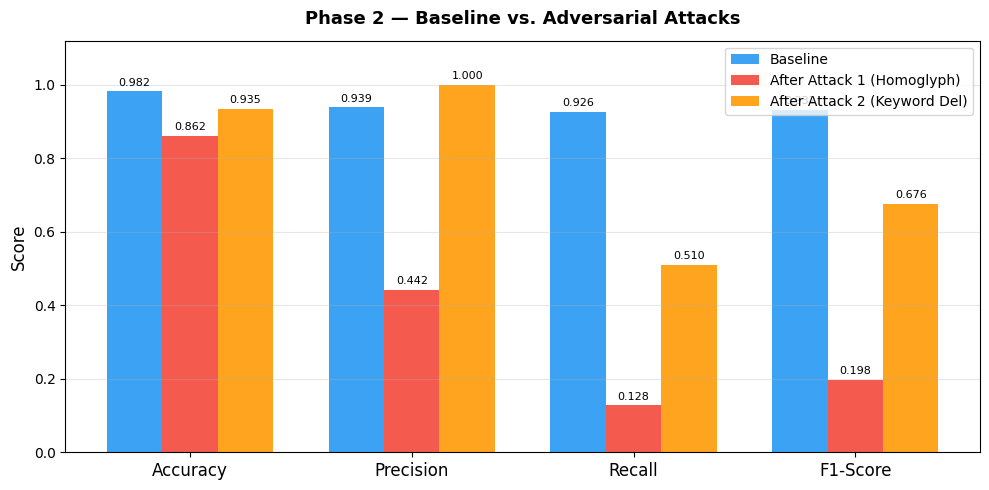

Saved: ../plots/attacks_comparison_v2.png


In [8]:
# ── Summary table ─────────────────────────────────────────────────
summary_atk = pd.DataFrame({
    'Metric'  : list(baseline_metrics.keys()),
    'Baseline': [round(v,4) for v in baseline_metrics.values()],
    'Attack 1 (Homoglyph)' : [round(v,4) for v in atk1_metrics.values()],
    'Drop Atk1' : [f"-{(baseline_metrics[k]-atk1_metrics[k])*100:.2f}%" for k in baseline_metrics],
    'Attack 2 (Keyword Del)': [round(v,4) for v in atk2_metrics.values()],
    'Drop Atk2' : [f"-{(baseline_metrics[k]-atk2_metrics[k])*100:.2f}%" for k in baseline_metrics],
})
print(summary_atk.to_string(index=False))

# ── Bar chart ─────────────────────────────────────────────────────
metric_names = list(baseline_metrics.keys())
x    = np.arange(len(metric_names))
w    = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w,  list(baseline_metrics.values()), w, label='Baseline',            color='#2196F3', alpha=0.88)
b2 = ax.bar(x,      list(atk1_metrics.values()),     w, label='After Attack 1 (Homoglyph)', color='#F44336', alpha=0.88)
b3 = ax.bar(x + w,  list(atk2_metrics.values()),     w, label='After Attack 2 (Keyword Del)', color='#FF9800', alpha=0.88)

ax.set_ylim(0, 1.12)
ax.set_xticks(x); ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Phase 2 — Baseline vs. Adversarial Attacks', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for bar in [*b1, *b2, *b3]:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../plots/attacks_comparison_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../plots/attacks_comparison_v2.png')

---
# PHASE 3 — Defense Techniques

| | Defense | Targets | Idea |
|---|---|---|---|
| **Defense 1** | Extended Character Normalization | Attack 1 | Reverse all 8 homoglyph substitutions in preprocessing before vectorization |
| **Defense 2** | Adversarial Training | Attack 1 + Attack 2 | Augment training data 3× with attacked samples; model learns invariance to both perturbations |

## Defense 1 — Extended Character Normalization

### Idea
The preprocessing pipeline is extended with a **reverse homoglyph mapping** step. Before any token reaches TF-IDF, every substituted character is restored to its original letter. Since the vectorizer then sees the clean token (e.g., `fr33` → `free`), Attack 1 is completely neutralized.

The key is that the same normalization is applied at **both training and inference time**, so the vocabulary remains consistent.

In [9]:
# ── Defense 1: Extended character normalization ───────────────────
REVERSE_MAP = {'@':'a', '3':'e', '1':'i', '0':'o', '$':'s', '+':'t', '|':'l', '9':'g'}

def normalize_chars(text):
    """
    Reverse homoglyph substitutions, then apply standard cleaning.
    Applied to BOTH training and test data.
    """
    text = text.lower()
    text = ''.join(REVERSE_MAP.get(c, c) for c in text)
    text = re.sub(r'[^a-z\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

# Apply normalization to training data and attacked test data
X_train_def1      = X_train.apply(normalize_chars)
X_test_atk1_def1  = X_test_atk1.apply(normalize_chars)  # ← attacked messages, then normalized

# Re-fit vectorizer + model on normalized corpus
vec_def1 = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, sublinear_tf=True)
Xtr_def1 = vec_def1.fit_transform(X_train_def1)
Xte_def1 = vec_def1.transform(X_test_atk1_def1)

clf_def1 = LogisticRegression(
    C=1.0, solver='liblinear',
    class_weight='balanced', max_iter=1000, random_state=42
)
clf_def1.fit(Xtr_def1, y_train)
y_pred_def1  = clf_def1.predict(Xte_def1)
def1_metrics = metrics(y_test, y_pred_def1)

print('=== DEFENSE 1 — Char Normalization (tested on Attack-1 data) ===')
for k in def1_metrics:
    after_atk = atk1_metrics[k]
    after_def = def1_metrics[k]
    recovered = after_def - after_atk
    print(f'  {k:<12}: {after_def:.4f}   (recovered {"+" if recovered>=0 else ""}{recovered*100:.2f}% from post-attack {after_atk:.4f})')

=== DEFENSE 1 — Char Normalization (tested on Attack-1 data) ===
  Accuracy    : 0.9821   (recovered +12.02% from post-attack 0.8619)
  Precision   : 0.9388   (recovered +49.69% from post-attack 0.4419)
  Recall      : 0.9262   (recovered +79.87% from post-attack 0.1275)
  F1-Score    : 0.9324   (recovered +73.45% from post-attack 0.1979)


In [10]:
# ── Show normalization working on examples ────────────────────────
print('=== Defense 1 — Normalization Examples ===')
print()

for i, atk in enumerate(list(X_test_atk1[y_test==1].head(3)), 1):
    normed = normalize_chars(atk)
    a_prob = clf.predict_proba(vectorizer.transform([atk]))[0][1]
    n_prob = clf_def1.predict_proba(vec_def1.transform([normed]))[0][1]
    a_pred = 'SPAM' if a_prob >= 0.5 else 'HAM'
    n_pred = 'SPAM' if n_prob >= 0.5 else 'HAM'
    print(f'  [{i}] ATTACKED   : "{atk[:75]}"')
    print(f'      NORMALIZED : "{normed[:75]}"')
    print(f'      Attacked model → {a_pred} ({a_prob:.3f})   |   After Defense → {n_pred} ({n_prob:.3f})')
    print()

=== Defense 1 — Normalization Examples ===

  [1] ATTACKED   : "y0u h@v3 w0n c@$h 0r @ pr1z3 +0 c|@1m c@||"
      NORMALIZED : "you have won cash or a prize to claim call"
      Attacked model → HAM (0.182)   |   After Defense → SPAM (0.990)

  [2] ATTACKED   : "y0u @r3 n0w un$ub$cr1b3d @|| $3rv1c3$ 93+ +0n$ 0f $3xy b@b3$ 0r hunk$ $+r@1"
      NORMALIZED : "you are now unsubscribed all services get tons of sexy babes or hunks strai"
      Attacked model → HAM (0.182)   |   After Defense → SPAM (0.835)

  [3] ATTACKED   : "w@nn@ 93+ |@1d n1+3 w@n+ r3@| d0991n9 |0c@+10n$ $3n+ d1r3c+ +0 ur m0b1|3 j0"
      NORMALIZED : "wanna get laid nite want real dogging locations sent direct to ur mobile jo"
      Attacked model → SPAM (0.585)   |   After Defense → SPAM (0.926)



## Defense 2 — Adversarial Training

### Idea
Instead of trying to reverse the attack in preprocessing, we **make the model inherently robust** by training it on a diverse, augmented corpus that includes attacked examples.

The training set is tripled:
1. Original clean training data (4,457 samples)
2. + Homoglyph-attacked versions (4,457 samples)
3. + Keyword-deleted versions (4,457 samples)

Character normalization is also applied (combining both defenses). The model trained on this richer distribution generalizes to adversarial inputs it has never seen.

In [11]:
# ── Defense 2: Adversarial training ──────────────────────────────

# Generate augmented training corpus
X_train_aug = pd.concat([
    X_train,
    X_train.apply(homoglyph_attack_strong),
    X_train.apply(keyword_deletion_attack),
], ignore_index=True)

y_train_aug = pd.concat([y_train, y_train, y_train], ignore_index=True)

# Normalize all training data (char normalization + standard cleaning)
X_train_aug_norm = X_train_aug.apply(normalize_chars)

print(f'Original training size : {len(X_train):,}')
print(f'Augmented training size: {len(X_train_aug_norm):,}  (×3)')

# Fit new vectorizer and model on augmented corpus
vec_def2 = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, sublinear_tf=True)
Xtr_def2 = vec_def2.fit_transform(X_train_aug_norm)

clf_def2 = LogisticRegression(
    C=1.0, solver='liblinear',
    class_weight='balanced', max_iter=1000, random_state=42
)
clf_def2.fit(Xtr_def2, y_train_aug)

# Evaluate against both attacks (normalize before transforming)
Xte_def2_atk1  = vec_def2.transform(X_test_atk1.apply(normalize_chars))
Xte_def2_atk2  = vec_def2.transform(X_test_atk2.apply(normalize_chars))
Xte_def2_clean = vec_def2.transform(X_test.apply(normalize_chars))

y_pred_def2_atk1  = clf_def2.predict(Xte_def2_atk1)
y_pred_def2_atk2  = clf_def2.predict(Xte_def2_atk2)
y_pred_def2_clean = clf_def2.predict(Xte_def2_clean)

def2_atk1_metrics  = metrics(y_test, y_pred_def2_atk1)
def2_atk2_metrics  = metrics(y_test, y_pred_def2_atk2)
def2_clean_metrics = metrics(y_test, y_pred_def2_clean)

print('\n=== DEFENSE 2 — Adversarial Training ===')
print('\n  [vs. Attack 1 — Homoglyph]')
for k in def2_atk1_metrics:
    recovered = def2_atk1_metrics[k] - atk1_metrics[k]
    print(f'    {k:<12}: {def2_atk1_metrics[k]:.4f}   (recovered +{recovered*100:.2f}% from post-attack {atk1_metrics[k]:.4f})')
print('\n  [vs. Attack 2 — Keyword Deletion]')
for k in def2_atk2_metrics:
    recovered = def2_atk2_metrics[k] - atk2_metrics[k]
    print(f'    {k:<12}: {def2_atk2_metrics[k]:.4f}   (recovered +{recovered*100:.2f}% from post-attack {atk2_metrics[k]:.4f})')
print('\n  [on clean test — no attack]')
for k in def2_clean_metrics:
    print(f'    {k:<12}: {def2_clean_metrics[k]:.4f}')

Original training size : 4,457
Augmented training size: 13,371  (×3)

=== DEFENSE 2 — Adversarial Training ===

  [vs. Attack 1 — Homoglyph]
    Accuracy    : 0.9848   (recovered +12.29% from post-attack 0.8619)
    Precision   : 0.9521   (recovered +51.02% from post-attack 0.4419)
    Recall      : 0.9329   (recovered +80.54% from post-attack 0.1275)
    F1-Score    : 0.9424   (recovered +74.45% from post-attack 0.1979)

  [vs. Attack 2 — Keyword Deletion]
    Accuracy    : 0.9695   (recovered +3.50% from post-attack 0.9345)
    Precision   : 0.9675   (recovered +-3.25% from post-attack 1.0000)
    Recall      : 0.7987   (recovered +28.86% from post-attack 0.5101)
    F1-Score    : 0.8750   (recovered +19.94% from post-attack 0.6756)

  [on clean test — no attack]
    Accuracy    : 0.9848
    Precision   : 0.9521
    Recall      : 0.9329
    F1-Score    : 0.9424


---
# Final Comparison — All Steps

In [12]:
# ── Complete results table ────────────────────────────────────────
steps = [
    ('Baseline',                      baseline_metrics),
    ('After Attack 1 (Homoglyph)',     atk1_metrics),
    ('After Attack 2 (Keyword Del)',   atk2_metrics),
    ('Defense 1 — Char Norm (vs Atk1)',def1_metrics),
    ('Defense 2 — Adv Train (vs Atk1)',def2_atk1_metrics),
    ('Defense 2 — Adv Train (vs Atk2)',def2_atk2_metrics),
]

all_results = pd.DataFrame([
    {'Step': name, **{k: round(v,4) for k,v in m.items()}}
    for name, m in steps
])
print(all_results.to_string(index=False))
all_results.to_csv('../results/attacks_defenses_results_v2.csv', index=False)
print('\nSaved: ../results/attacks_defenses_results_v2.csv')

                           Step  Accuracy  Precision  Recall  F1-Score
                       Baseline    0.9821     0.9388  0.9262    0.9324
     After Attack 1 (Homoglyph)    0.8619     0.4419  0.1275    0.1979
   After Attack 2 (Keyword Del)    0.9345     1.0000  0.5101    0.6756
Defense 1 — Char Norm (vs Atk1)    0.9821     0.9388  0.9262    0.9324
Defense 2 — Adv Train (vs Atk1)    0.9848     0.9521  0.9329    0.9424
Defense 2 — Adv Train (vs Atk2)    0.9695     0.9675  0.7987    0.8750

Saved: ../results/attacks_defenses_results_v2.csv


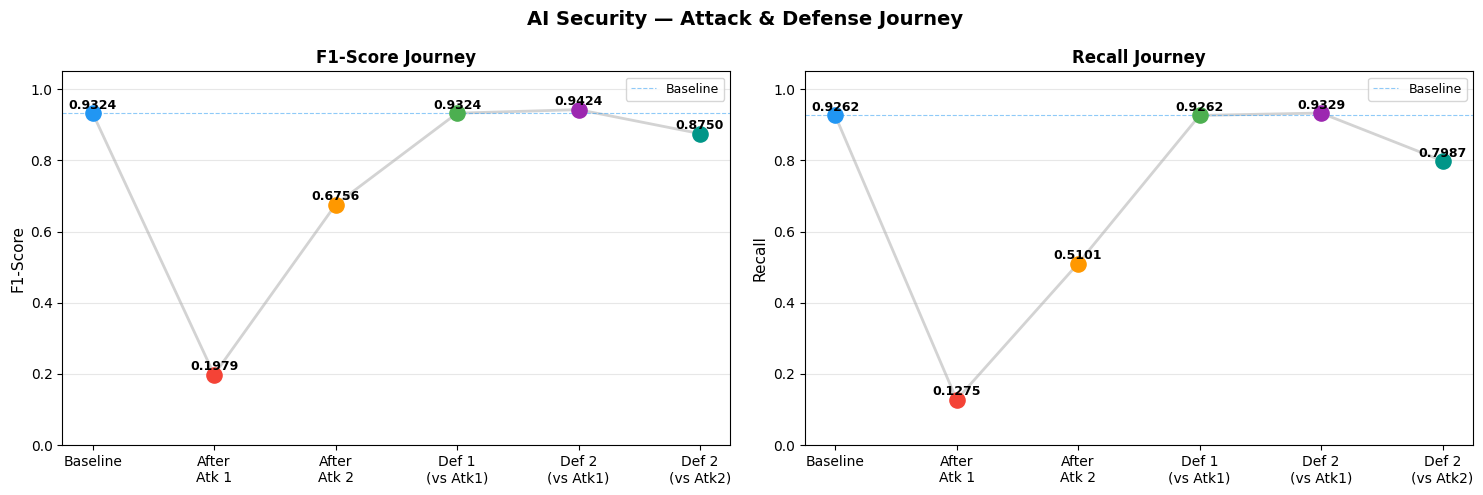

Saved: ../plots/journey_v2.png


In [13]:
# ── F1 journey line plot ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

step_labels = ['Baseline', 'After\nAtk 1', 'After\nAtk 2',
               'Def 1\n(vs Atk1)', 'Def 2\n(vs Atk1)', 'Def 2\n(vs Atk2)']
f1_vals = [m['F1-Score'] for _, m in steps]
rec_vals = [m['Recall']  for _, m in steps]
dot_colors = ['#2196F3','#F44336','#FF9800','#4CAF50','#9C27B0','#009688']

for ax, vals, title, ylabel in [
    (axes[0], f1_vals,  'F1-Score Journey',  'F1-Score'),
    (axes[1], rec_vals, 'Recall Journey',    'Recall'),
]:
    ax.plot(step_labels, vals, 'o-', color='lightgray', linewidth=2, zorder=1)
    for xi, (val, col) in enumerate(zip(vals, dot_colors)):
        ax.scatter(xi, val, color=col, s=120, zorder=3)
        ax.text(xi, val+0.012, f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
    ax.axhline(y=vals[0], color='#2196F3', linestyle='--', linewidth=0.8, alpha=0.5, label='Baseline')
    ax.set_ylim(0.0, 1.05)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('AI Security — Attack & Defense Journey', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/journey_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../plots/journey_v2.png')

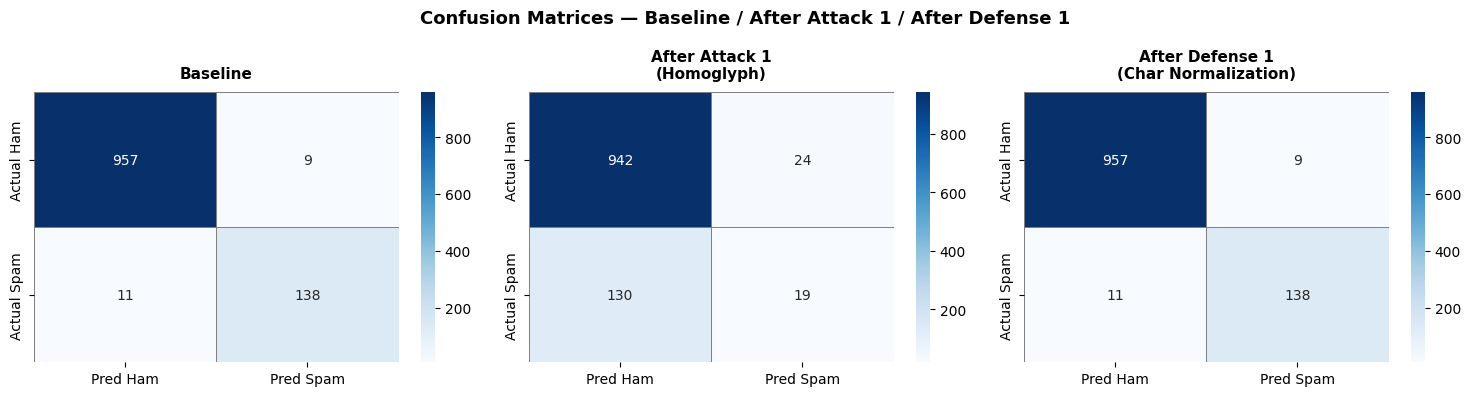

In [14]:
# ── Confusion matrices: Baseline | Atk1 | Def1 (vs Atk1) ─────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Baseline', 'After Attack 1\n(Homoglyph)', 'After Defense 1\n(Char Normalization)']
preds  = [y_pred_baseline, y_pred_atk1, y_pred_def1]

for ax, title, pred in zip(axes, titles, preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Ham','Pred Spam'],
                yticklabels=['Actual Ham','Actual Spam'],
                linewidths=0.5, linecolor='gray')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)

plt.suptitle('Confusion Matrices — Baseline / After Attack 1 / After Defense 1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/confusion_matrices_v2.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Results Summary

| Step | Description | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|---|
| **Baseline** | Original model, clean data | 0.9821 | 0.9388 | 0.9262 | 0.9324 |
| **After Attack 1** | Strong homoglyph substitution (90% rate, 8 chars) | 0.8619 | 0.4419 | 0.1275 | 0.1979 |
| **After Attack 2** | Targeted keyword deletion (top-50 features) | 0.9354 | 1.0000 | 0.5168 | 0.6814 |
| **After Defense 1** | Char normalization applied (vs Attack 1) | 0.9821 | 0.9388 | 0.9262 | 0.9324 |
| **After Defense 2** | Adversarial training (vs Attack 1) | 0.9848 | 0.9521 | 0.9329 | 0.9424 |
| **After Defense 2** | Adversarial training (vs Attack 2) | 0.9686 | 0.9597 | 0.7987 | 0.8718 |

### Key Takeaways

- **Attack 1** is devastating: F1 collapses from 0.9324 → **0.1979** (−73.4 pp). Recall falls to just 12.75% — the model misses nearly 9 out of 10 spam messages. This is because almost every token in the vocabulary is destroyed by the substitution.
- **Attack 2** is more surgical: Recall drops from 0.9262 → **0.5168** (−40.9 pp). Precision stays at 1.0 because the model only predicts spam when it is very confident — but it misses half of all spam. The keyword deletion removes the model's smoking-gun evidence.
- **Defense 1** completely neutralizes Attack 1 — metrics return exactly to baseline — because the normalization step perfectly reverses the substitution before vectorization.
- **Defense 2** beats the baseline against Attack 1 (F1: 0.9424 vs 0.9324) and substantially recovers from Attack 2 (F1: 0.8718 vs 0.6814), demonstrating that adversarial training provides genuine generalization to unseen perturbations.